# Summary
The notebook shows how to run the _Multiscale Non-stationary Causal Structure Learner_ (MN-CASTLE) onto synthetic data.

In [1]:
import gpytorch
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pyro
import torch

from distributions.Plackett_Luce import make_permutation_matrix
from generators.probabilistic_generator import Generator
from metrics import count_accuracy, get_CPDAG
from models.deep_probabilistic.MNCASTLE import CausalOrder, CausalCoeff
from pyro.infer import SVI, TraceGraph_ELBO
from pyro.optim import ClippedAdam
from tqdm.notebook import tqdm
from utils import _block_diag

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
plt.rcParams['text.usetex'] = True

# Generate synthetic data

For an overview of the synthetic generator, please see the notebook ```example_datagen.ipynb```.
Here, we generate a system constituted by $N=5$ time series, each of length $T=100$.
As far as _non-stationarity_ and _multiscale_ features, we set $\tau=.5$ and $\mu=.5$, respectively.
Finally, the density to manage the causal structure density we specify $\delta=.5$.

In [4]:
T=100
N=5
multiscale=.5
nonstationarity=.5
density=.5

In [5]:
gen = Generator(N=N, T=T, multiscale=multiscale, nonstationarity=nonstationarity, density=density)
X=gen.generate()

In [6]:
print(r'Causal ordering={}; Total number of time scales J={}.'.format(gen.ordering.numpy(), gen.J.item()))

Causal ordering=[4 1 3 0 2]; Total number of time scales J=3.


# Inference

In the code below we set up the inference procedure.

In particular, we specifify MN-CASTLE to use radial basis functions kernel, $K_{\text{RBF}}$, for modeling the latent causal coefficients by means of batched $GP$s.  

Then, in the ```per_param_callable``` function we allow parameters to have different (decaying) learning rates.

Next, ```Alternating2steps``` function represents the training function.
We instantiate the probabilistic models for causal ordering and for causal coefficients, along with optimizer, loss and stochastic variational inference.
At this point, we iterate until ```num_iter``` is reached. 
Within each loop, we firstly optimize w.r.t. the causal ordering, then we compute the mode of the Plackett-Luce distribution $\hat{\prec}^{0}$ and we use it to optimize w.r.t. the causal coefficients.
Since $\hat{\prec}^{0}$ is more stable across inference steps than causal orderings directly sampled from the Plackett-Luce distribution, we obtain a smoother learning process for causal coefficients.
However, this two step procedure has not any theorethical guarantee to converge to the global optimum.

Finally, we use ```percentiles_from_samples``` function to compute the confidence interval of the estimated causal structure. 

In [7]:
#MN-CASTLE kernel
kernel =  gpytorch.kernels.RBFKernel(lengthscale_constraint=gpytorch.constraints.GreaterThan(1.),lengthscale_prior=None)

#rescaled time
train_x = torch.linspace(0, 1, T).view(1,1,1,-1,1).repeat(gen.J,N,N,1,1)

In [8]:
#adapted from https://github.com/cornellius-gp/gpytorch/blob/master/examples/07_Pyro_Integration/Cox_Process_Example.ipynb
#function to compute confidence intervals
def percentiles_from_samples(samples, percentiles=[0.01, 0.5, 0.99]):
    num_samples = samples.size(0)
    samples = samples.sort(dim=0)[0]

    # Get samples corresponding to percentile
    percentile_samples = [samples[int(num_samples * percentile)] for percentile in percentiles]

    return percentile_samples

In [9]:
pyro.clear_param_store()

#number of inference steps and particles
num_iter =100
num_particles=10

#function to specify different learning rates
#for models parameters
def per_param_callable(param_name):
    global num_iter
    gamma = .1  # final learning rate will be gamma * initial_lr
    lrd = gamma ** (1 / num_iter) #decaying learning rate
    
    #param associated with the avg deacying baseline used
    #to stabilize the variance of gradient estimator
    #for causal ordering estimation
    if 'baseline' in param_name:
        return {"lr":.03, 'betas':(.95,.999)}
    elif 'gp' in param_name:
        return {"lr":.03, 'lrd':lrd} #params of batched GPs. Here we use decaying lr.
    else:
        return {"lr": .03, 'betas':(.95,.999), 'lrd':lrd} #other params. Here we use decaying lr.

#Alternating two steps inference procedure.
def Alternating2steps(train_x, X, S, kernel):
    """
    INPUT
    =====
    - train_x: torch tensor of size (J,N,N,T,1). Rescaled time.
    - X: torch tensor of size (T,N). Observed time series values.
    - S: torch tensor of size (J,T,N,N). Estimate of power spectrum.
    - kernel: gpytorch kernel object. Kernel used by MN-CASTLE to model latent GPs.

    OUTPUT
    ======
    dict of estimated parameters.
    """
    J, T, N,_= S.size()
    model_order = CausalOrder(T,N) #model for causal ordering
    model_coeff = CausalCoeff(J,T,N,kernel=kernel, frac_inducing=.64) #model for causal coefficients
    pyro.clear_param_store()
    optimizer = ClippedAdam(per_param_callable) #optimizer
    elbo = TraceGraph_ELBO(num_particles=num_particles, vectorize_particles=False, retain_graph=True) #loss function
    svi_order = SVI(model_order.model, model_order.guide, optimizer, elbo) #svi for causal ordering
    svi_coeff = SVI(model_coeff.model, model_coeff.guide, optimizer, elbo) #svi for causal coefficients

    #training 
    model_coeff.train()
    iterator = tqdm(range(num_iter))
    for i in iterator:
        model_coeff.zero_grad()
        loss_order = svi_order.step(X) #optimize w.r.t. causal ordering
        _b = pyro.param(model_order.name_prefix+'.theta').detach().data 
        _, _order = _b.sort(descending=True) #retain the mode of PL distribution
        
        #At the beginning the model assigns equal scores
        #to all nodes and this tend to break the inference of GPs.
        #Therefore, we allow the model to differentiate nodes scores 
        #for the first 25 iterations. 
        if i>25:
            loss_coeff = svi_coeff.step(train_x, _order, S) #optimize w.r.t. causal coefficients
            #print params value
            iterator.set_postfix(loss_order=loss_order,
                                 b=_b,
                                 loss_coeff=loss_coeff,
                                 nonstationarity=1./model_coeff.covar_module.base_kernel.lengthscale.detach().item())
        else:
            #print params value
            iterator.set_postfix(loss_order=loss_order,
                                 b=_b)
        
    test_x = torch.linspace(0, 1, T).float()
    
    #put the model in evaluation mode
    model_coeff.eval()
    
    with torch.no_grad():
        output = model_coeff(test_x)    

    #compute confidence intervals for causal coefficients    
    Nsamples = 1000
    samples=output(torch.Size([Nsamples]))
    lower, mean, upper = percentiles_from_samples(samples)
    ac_mean=mean.transpose(1,-1).transpose(-2,-1)
    ac_upper=upper.transpose(1,-1).transpose(-2,-1)
    ac_lower=lower.transpose(1,-1).transpose(-2,-1)
    
    #store the estimated parameters
    theta_hat, co = pyro.param(model_order.name_prefix+".theta").cpu().detach().data.sort(descending=True)
    lengthscale = model_coeff.covar_module.base_kernel.lengthscale.cpu().detach().item()
    nonstationarity = 1./lengthscale
    c0 = model_coeff.mean_module.constant.cpu().detach().data.squeeze()
    return {
        'mean_GP': c0.numpy(),
        'ac_mean':ac_mean.numpy(),
        'ac_upper':ac_upper.numpy(),
        'ac_lower':ac_lower.numpy(),
        'b':theta_hat.numpy(),
        'causal ordering':co.numpy(),
        'lengthscale':lengthscale,
        'nonstationarity':nonstationarity}

In [10]:
%time results=Alternating2steps(train_x, X, gen.S, kernel) #use custom kernel
# %time results=Alternating2steps(train_x, X, gen.S, None) #uses Matern5/2 as default

  0%|          | 0/100 [00:00<?, ?it/s]

Wall time: 1min 27s


# Plot results

Here we plot estimated causal coefficients along with C.I. vs the ground truth.

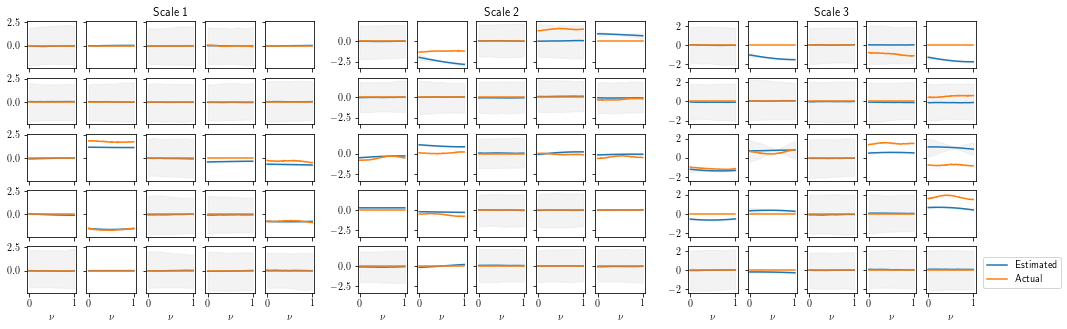

In [11]:
test_x = torch.linspace(0, 1, T).float()

fig = plt.figure(figsize=(17,5))
outer_grid = fig.add_gridspec(1, int(gen.J), wspace=0.15, hspace=0)

for scale in range(gen.J):

    inner_grid = outer_grid[scale].subgridspec(5, 5, wspace=0.2, hspace=0.2)
    title_ax = fig.add_subplot(inner_grid[:])
    title_ax.axis('off')
    title_ax.set_title('Scale {}'.format(scale+1))
    ax = inner_grid.subplots(sharey=True, sharex=True)
    
    for i,j in itertools.product(range(gen.N), range(gen.N)):
        ax[i,j].plot(test_x, results['ac_mean'][scale,:,i,j], label='Estimated')
        ax[i,j].fill_between(
            test_x, results['ac_lower'][scale,:,i,j],
            results['ac_upper'][scale,:,i,j], color='#d9d9d9', alpha=0.3
        )

        ax[i,j].plot(test_x, gen.C[scale,-T:,i,j], label='Actual')
       
        if i==N-1: ax[i,j].set_xlabel("$\\nu$")
       
ax[i,j].legend(bbox_to_anchor=[1.05, 0.], loc='lower left')

plt.show()

# Metrics
Below we provide performace metrics for the estimted causal adjacency tensor.

In [12]:
causal_adj = torch.zeros(results['mean_GP'].shape)
for j,n,m in itertools.product(range(causal_adj.shape[0]),range(causal_adj.shape[1]),range(causal_adj.shape[2])):
    
    hard_thresh=(np.minimum(np.abs(results['ac_lower'][j,:,n,m]),np.abs(results['ac_upper'][j,:,n,m]))>.1).sum()
    confidence=(np.sign(results['ac_lower'][j,:,n,m]*results['ac_upper'][j,:,n,m])).sum()

    #we register a causal connection if the causal coefficient is greater than .1 in abs value at 99% level
    #and lower and upper bounds have same sign.
    if hard_thresh>0 and confidence!=-results['ac_mean'].shape[1]: 
        causal_adj[j,n,m]+=1.

In [13]:
#here we compute the masking tensor
#for imposing the causal ordering
ordering_est = results['causal ordering'] 
B=torch.tril(torch.ones([N,N]), diagonal=-1)
P_=make_permutation_matrix(torch.tensor(ordering_est)).to(device)
B=(P_.T@B@P_).expand(gen.J,N,N)
causal_adj1 = B*causal_adj
print(ordering_est, gen.ordering)

[1 4 0 3 2] tensor([4, 1, 3, 0, 2])


In [14]:
#compute the metrics
td=get_CPDAG(_block_diag(torch.abs(torch.sign(gen.C[:,0])).numpy()))
est=get_CPDAG(_block_diag((causal_adj1).numpy()))
count_accuracy(td, est)

{'fdr|(1-precision)': 0.391304347826087,
 'tpr|recall': 0.7,
 'fpr': 0.10588235294117647,
 'f1': 0.6511627906976745,
 'shd-missing': 2,
 'shd-extra': 5,
 'shd-reverse': 4,
 'shd': 11,
 'pred-und': 0,
 'f-und': 0.0,
 'nnz': 23,
 'true_nnz': 20,
 'ae_nnz': 3}